# NaCl diffusion (FEniCSx + GEMS)

Reproduces fenics-reaktoro `Demos/NaCl_diffusion` with the four modules in
`FEniCSx_GEMS_Beginner` (two folders up). All settings are in `case.yaml`; the code cells
only run it and plot. Nothing needs editing.

Two NaCl solutions touch at the middle of a 20 mm column: 1 M on the left, 0.5 M on the
right. Each end is held at its own solution. Salt diffuses from left to right.

| Quantity | Original | `case.yaml` |
|---|---|---|
| Domain | −10 … 10 mm, 200 cells | 0 … 20 mm, 200 cells (interface at 10 mm) |
| Solutions | GEMS `nacl` (1 M), `naclLOW` (0.5 M) | `chemistry.initial.high`, `.low` |
| Zones | cells 0–99 high, 100–199 low | `transport.zones` |
| Boundaries | both ends fixed at the adjacent solution | `inlet: {left: high, right: low}` |
| Transport | Nernst–Planck, $D_{\mathrm{Na}}$ = 1.334e-9, $D_{\mathrm{Cl}}$ = 2.032e-9 m²/s | Fick, $D_{\mathrm{salt}}$ = 1.611e-9 m²/s |
| Time | 100 s, $\Delta t$ = 1 s | same |

## Transport: why one diffusion coefficient is exact here

Nernst–Planck for ion $i$ with charge $z_i$ and potential $\psi$:

$$
\frac{\partial c_i}{\partial t} = \frac{\partial}{\partial x}\Bigl(D_i\frac{\partial c_i}{\partial x}
 + \frac{z_i F}{RT} D_i c_i \frac{\partial \psi}{\partial x}\Bigr).
$$

For a 1:1 salt with electroneutrality ($c_{\mathrm{Na}} = c_{\mathrm{Cl}} = c$) and no current,
the electric field makes the fast Cl⁻ and slow Na⁺ move together, and both equations reduce to

$$
\frac{\partial c}{\partial t} = D_{\mathrm{salt}}\frac{\partial^2 c}{\partial x^2},
\qquad D_{\mathrm{salt}} = \frac{2D_{\mathrm{Na}}D_{\mathrm{Cl}}}{D_{\mathrm{Na}}+D_{\mathrm{Cl}}} = 1.611\times10^{-9}\ \mathrm{m^2/s}.
$$

So `transport.py` with $\phi = 1$ and $D_e = D_{\mathrm{salt}}$ solves the same problem
(H⁺/OH⁻ at 10⁻⁷ M are negligible). The discretisation is DG0 finite volume with backward
Euler, as described in the other demos.

The analytic solution for two semi-infinite halves (the 100 s diffusion length, 0.8 mm, is
far from the ends at ±10 mm):

$$
c(x,t) = \frac{c_H + c_L}{2} - \frac{c_H - c_L}{2}\,\operatorname{erf}\!\left(\frac{x - x_0}{2\sqrt{D_{\mathrm{salt}}\,t}}\right).
$$

**Zones.** `transport.zones` splits the column into named parts; a cell belongs to a zone when
its centre lies in `[from, to)`, and the zone may set its own `phi` and `De`.
`chemistry.initial` then gives one recipe per zone name. At a zone interface the face
diffusivity is the harmonic mean $2D_{e,i}D_{e,i+1}/(D_{e,i}+D_{e,i+1})$, which keeps the flux
continuous.

## Chemistry

Only an aqueous phase (`solid_phases: []`), so GEMS just speciates the solution. The two zone
recipes are the GEMS DBR states `nacl` and `naclLOW`, scaled to 1 dm³. Each boundary solution
is the equilibrated pore water of its zone (`inlet: {left: high, right: low}`).

## SNIA coupling (`coupling.py`)

Once per time step: (1) diffuse the dissolved element amounts, minerals fixed;
(2) `total = immobile + aqueous`; (3) GEMS equilibrium in every cell;
(4) check that the column inventory changed only by what crossed the boundaries.

## Settings

The file that is run:

In [4]:
print(open("case.yaml", encoding="utf-8").read())

# NaCl diffusion between two NaCl solutions (fenics-reaktoro Demos/NaCl_diffusion),
# with the four modules two folders up (FEniCSx_GEMS_Beginner).
# Run from this folder:  python ../../coupling.py case.yaml   (or Run.cmd, or the notebook)
#
# Original: 20 mm of free solution, 1 M NaCl on the left half, 0.5 M on the right half,
# both ends held at their initial solution, Nernst-Planck transport, 100 s, dt = 1 s.
# Here x runs 0..0.02 m (original -0.01..0.01 m), interface at x = 0.01 m.

# 1. chemistry.py: GEMS project, chemical conditions, and recipes.
chemistry:
  project: chemistry_data/nacl-dat.lst
  temperature: 298.15                  # K
  pressure: 100000                     # Pa
  aqueous_phase: aq_gen
  solid_phases: []                     # solution only
  gibbs: {}

  # Sample per zone: element amounts in mol per 1 dm3 of BULK (= 1 dm3 of solution here).
  # = the GEMS DBR states nacl (1 M) and naclLOW (0.5 M), scaled to 1 dm3.
  initial:
    high:
      Cl: 0.98127723044314

## Run

Same as double-clicking `Run.cmd`.

In [5]:
import sys
!{sys.executable} ../../coupling.py case.yaml

[2026-09-24 16:38:05.194] [gems3k] [info] Home directory is /home/xi_b
step=0, time=0 s, balance=0.000e+00 mol/m2, chemistry=4.789e-09 mol/m3, water mismatch=0.00%
step=20, time=20 s, balance=1.376e-11 mol/m2, chemistry=1.062e-08 mol/m3, water mismatch=0.00%
step=40, time=40 s, balance=2.150e-11 mol/m2, chemistry=1.063e-08 mol/m3, water mismatch=0.00%
step=60, time=60 s, balance=3.153e-11 mol/m2, chemistry=1.050e-08 mol/m3, water mismatch=0.00%
step=80, time=80 s, balance=3.929e-11 mol/m2, chemistry=1.033e-08 mol/m3, water mismatch=0.00%
step=100, time=100 s, balance=4.765e-11 mol/m2, chemistry=1.060e-08 mol/m3, water mismatch=0.00%
Saved: /mnt/c/Users/xi_b/3D Objects/suduko/GEMS-FENICSX/FEniCSx_GEMS_Beginner/example/demo_NaCl_diffusion/results


## Results

`summary.txt` and the overview plot from `output.py`.

COMPLETED
Mode: coupled
Cells/states: 200; reference length: 0.02 m
Scheme: backward Euler, DG0 two-point cell flux (transport modes only)
Linear solver: preonly / lu
Final time: 100.0 s; steps: 100
Amounts: mol/m3 bulk; concentrations: mol/m3 pore water
Inventory and boundary exchange: mol/m2 (unit cross-sectional area)
Maximum balance error: 4.765341e-11 mol/m2
Maximum chemical element reconstruction error: 2.020784e-08 mol/m3
Maximum aqueous-volume/porosity mismatch: 0.000376%
GEMS initialisation: independent cold start for every equilibrium call
Final porosity range: 1 to 1
Final De range: 1.61062864e-09 to 1.61062864e-09 m2/s
Porosity feedback: False
Diffusivity feedback: False
Limit: numerical demonstration, not experimental validation.
Limit: saturated pore volume is assumed; aqueous volume mismatch is diagnostic only.



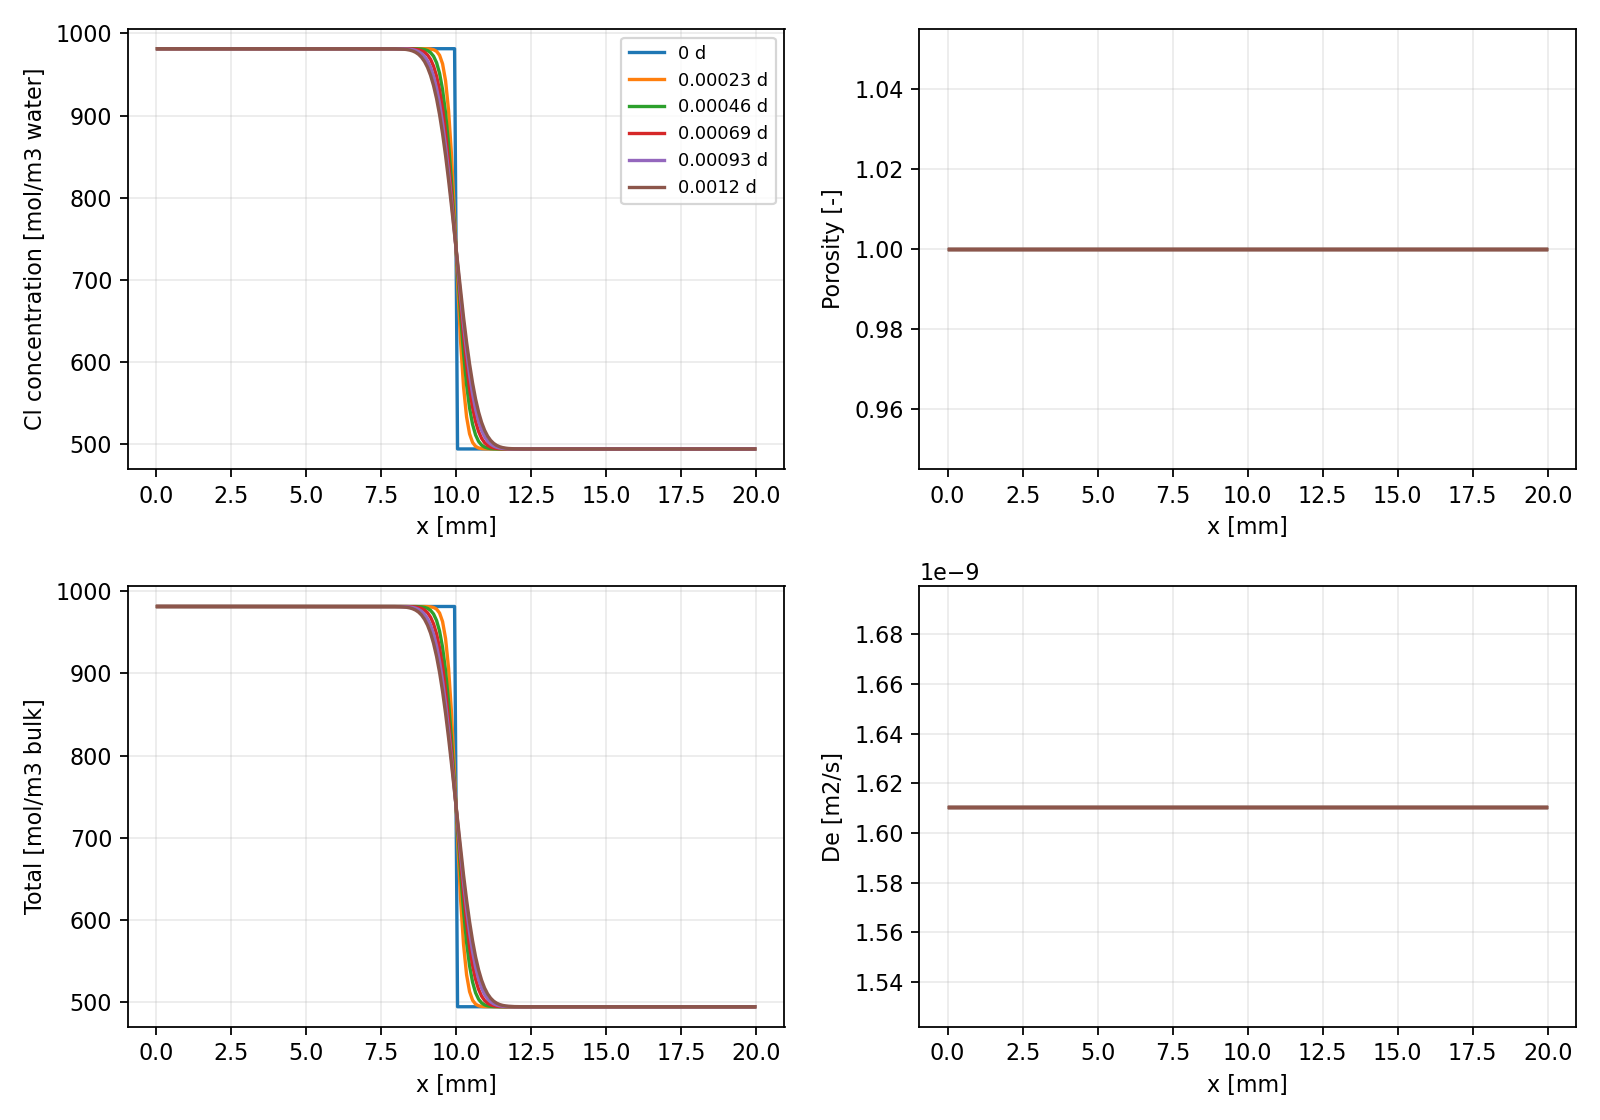

In [6]:
%matplotlib inline
import yaml
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd, matplotlib.pyplot as plt

case = yaml.safe_load(open("case.yaml"))
results = Path(case["output"]["folder"])
print((results / "summary.txt").read_text())
display(Image(filename=str(results / "profiles.png")))
p = pd.read_csv(results / "profiles.csv")

## Comparison with the analytic solution

Dots: this model (cell centres). Lines: erf solution with $D_{\mathrm{salt}}$.
x is shifted by −10 mm to the original coordinates.

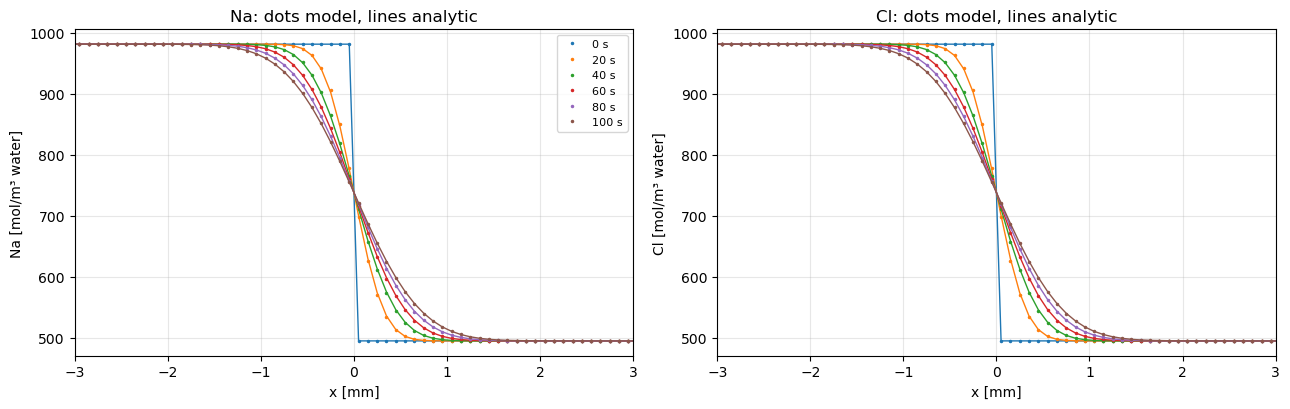

largest |model - analytic| / c_high over all saved times: 0.431 %


In [7]:
from scipy.special import erf

D = case["transport"]["material"]["De"]
x0 = 0.01
p0 = p[p["time_s"] == 0].sort_values("x_m")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
worst = 0.0
for ax, e in zip(axes, ("Na", "Cl")):
    col = f"{e}_c_mol_m3_water"
    cH, cL = p0[col].iloc[0], p0[col].iloc[-1]
    for k, (t, g) in enumerate(p.groupby("time_s")):
        g = g.sort_values("x_m")
        x = g["x_m"].to_numpy()
        exact = (cH + cL) / 2 if t == 0 else (cH + cL) / 2 - (cH - cL) / 2 * erf((x - x0) / (2 * np.sqrt(D * t)))
        if t == 0:
            exact = np.where(x < x0, cH, cL)
        ax.plot((x - x0) * 1e3, g[col], ".", ms=3, color=f"C{k}", label=f"{t:g} s")
        ax.plot((x - x0) * 1e3, exact, "-", lw=1, color=f"C{k}")
        worst = max(worst, np.max(np.abs(g[col].to_numpy() - exact)) / cH) if t > 0 else worst
    ax.set(xlim=(-3, 3), xlabel="x [mm]", ylabel=f"{e} [mol/m³ water]", title=f"{e}: dots model, lines analytic")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print(f"largest |model - analytic| / c_high over all saved times: {100 * worst:.3f} %")

## Differences to the original

| | Original | This model |
|---|---|---|
| Transport | Nernst–Planck, CG1, species | Fick with $D_{\mathrm{salt}}$, DG0, elements (exact for a 1:1 salt) |
| Chemistry | none (`transportOnly = yes`) | GEMS speciation of the solution each step |
| Coordinates | −10 … 10 mm | 0 … 20 mm |